Libraries imported successfully.
Dataset loaded successfully.
Vectorizer loaded successfully.
Intent model loaded successfully.
Intent encoder loaded successfully.
Emotion model loaded successfully.
Emotion encoder loaded successfully.

INTENT MODEL RESULTS
Accuracy: 0.7000
Total intent classes: 11
Classes in test set: 6
Intent class names:
['anger' 'anxiety' 'confusion' 'depression' 'loneliness' 'low_self_esteem'
 'positive' 'sadness' 'seeking_help' 'sleep_issues' 'stress']
                 precision    recall  f1-score   support

          anger       1.00      1.00      1.00         1
        anxiety       0.00      0.00      0.00         0
      confusion       0.67      0.67      0.67         3
     depression       0.00      0.00      0.00         0
     loneliness       0.00      0.00      0.00         1
low_self_esteem       1.00      0.67      0.80         3
       positive       0.00      0.00      0.00         0
        sadness       0.00      0.00      0.00         0
   see

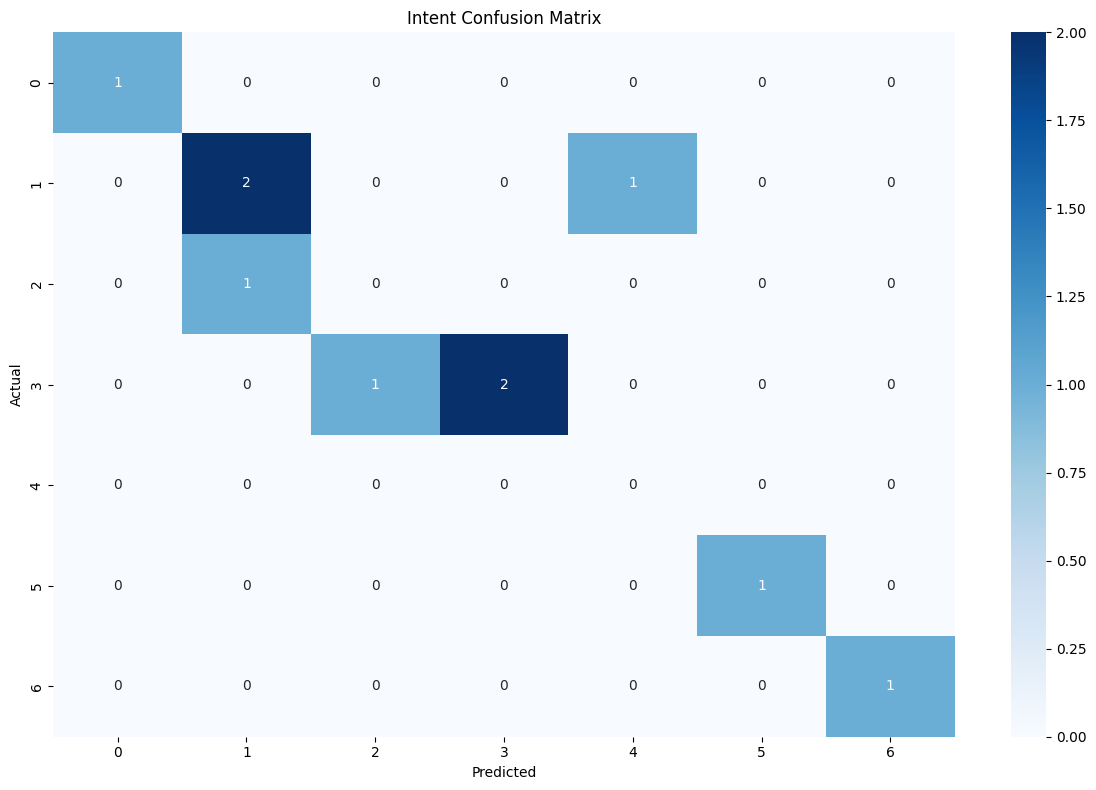


EMOTION MODEL RESULTS
Accuracy: 0.6000
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00         1
     anxious       0.00      0.00      0.00         0
    confused       1.00      0.67      0.80         3
     despair       1.00      1.00      1.00         1
   exhausted       0.00      0.00      0.00         1
        fear       0.00      0.00      0.00         0
  frustrated       0.00      0.00      0.00         1
       happy       0.00      0.00      0.00         0
     hopeful       0.00      0.00      0.00         0
         sad       0.43      1.00      0.60         3

    accuracy                           0.60        10
   macro avg       0.24      0.27      0.24        10
weighted avg       0.53      0.60      0.52        10



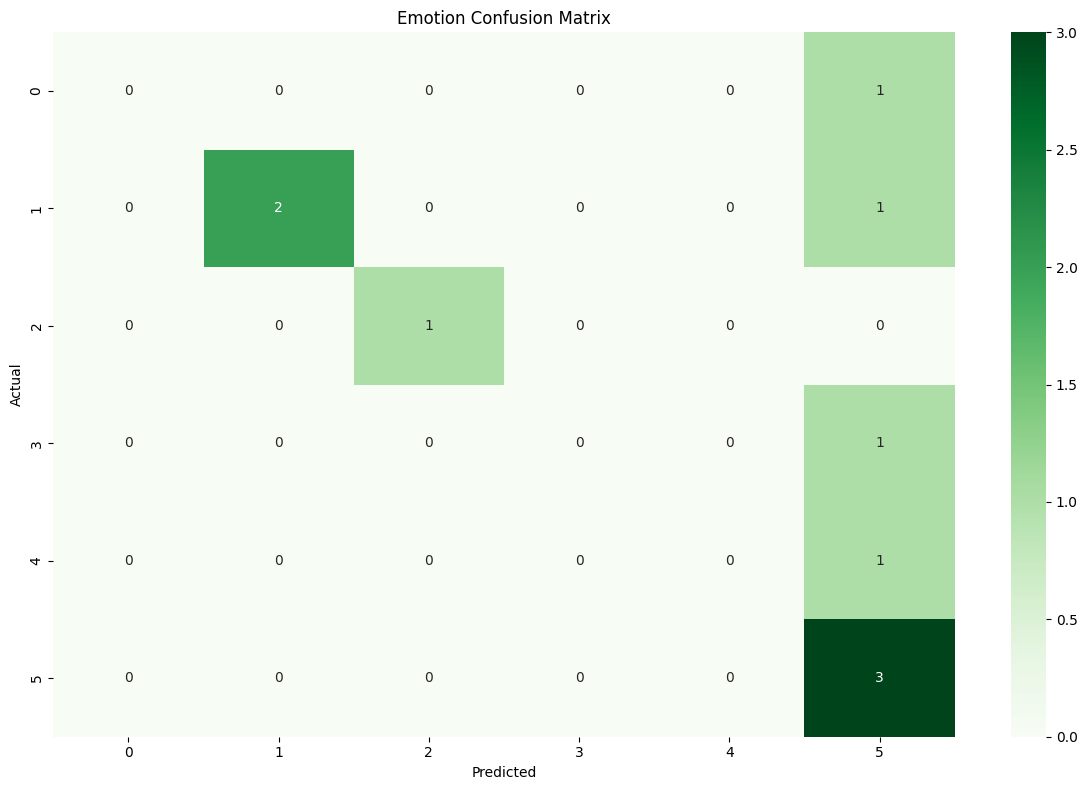


Human evaluation template saved.

Evaluation Completed Successfully!


In [9]:
# IMPORT LIBRARIES
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
print("Libraries imported successfully.")

# LOAD DATASET
df = pd.read_csv("../data/final_processed_dataset.csv")
print("Dataset loaded successfully.")

# LOAD VECTORIZER
with open(
    "../models/tfidf_vectorizer.pkl",
    "rb"
) as file:
    vectorizer = pickle.load(file)
print("Vectorizer loaded successfully.")

# LOAD INTENT MODEL
with open(
    "../models/intent_model.pkl",
    "rb"
) as file:
    intent_model = pickle.load(file)
print("Intent model loaded successfully.")

# LOAD INTENT ENCODER
with open(
    "../models/intent_encoder.pkl",
    "rb"
) as file:
    intent_encoder = pickle.load(file)
print("Intent encoder loaded successfully.")

# LOAD EMOTION MODEL
with open(
    "../models/emotion_model.pkl",
    "rb"
) as file:
    emotion_model = pickle.load(file)
print("Emotion model loaded successfully.")

# LOAD EMOTION ENCODER
with open(
    "../models/emotion_encoder.pkl",
    "rb"
) as file:
    emotion_encoder = pickle.load(file)
print("Emotion encoder loaded successfully.")

# PREPARE DATA
X = df["processed_text"]

# INTENT DATA
y_intent = intent_encoder.transform(
    df["intent"]
)

# EMOTION DATA

y_emotion = emotion_encoder.transform(
    df["emotion"]
)

# TRAIN TEST SPLIT
X_train,X_test,y_intent_train,y_intent_test = train_test_split(
    X,
    y_intent,
    test_size=0.2,
    random_state=42
)

# TF-IDF TRANSFORM

X_test_tfidf = vectorizer.transform(
    X_test
)

# INTENT PREDICTION
intent_predictions = intent_model.predict(
    X_test_tfidf
)

# INTENT ACCURACY

intent_accuracy = accuracy_score(
    y_intent_test,
    intent_predictions
)
print("\n==============================")
print("INTENT MODEL RESULTS")
print("==============================")
print(
    f"Accuracy: {intent_accuracy:.4f}"
)
#rrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr
print("Total intent classes:",
      len(intent_encoder.classes_))

print("Classes in test set:",
      len(set(y_intent_test)))

print("Intent class names:")
print(intent_encoder.classes_)

# INTENT REPORT
intent_report = classification_report(
    y_intent_test,
    intent_predictions,
    labels=range(len(intent_encoder.classes_)),
    target_names=intent_encoder.classes_,
    zero_division=0
)
print(intent_report)

# SAVE INTENT REPORT
with open(
    "../metrics/intent_report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(
        f"Accuracy: {intent_accuracy:.4f}\n\n"
    )
    file.write(intent_report)

# INTENT CONFUSION MATRIX
intent_cm = confusion_matrix(
    y_intent_test,
    intent_predictions
)

plt.figure(figsize=(12,8))
sns.heatmap(
    intent_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title(
    "Intent Confusion Matrix"
)
plt.xlabel(
    "Predicted"
)
plt.ylabel(
    "Actual"
)
plt.tight_layout()
plt.show()
plt.savefig(
    "../results/intent_confusion_matrix.png"
)
plt.close()

# EMOTION SPLIT
X_train,X_test,y_emotion_train,y_emotion_test = train_test_split(
    X,
    y_emotion,
    test_size=0.2,
    random_state=42
)

# TF-IDF TRANSFORM
X_test_tfidf = vectorizer.transform(
    X_test
)

# EMOTION PREDICTIONS
emotion_predictions = emotion_model.predict(
    X_test_tfidf
)

# EMOTION ACCURACY
emotion_accuracy = accuracy_score(
    y_emotion_test,
    emotion_predictions
)
print("\n==============================")
print("EMOTION MODEL RESULTS")
print("==============================")
print(
    f"Accuracy: {emotion_accuracy:.4f}"
)

# EMOTION REPORT
emotion_report = classification_report(
    y_emotion_test,
    emotion_predictions,
    labels=range(len(emotion_encoder.classes_)),
    target_names=emotion_encoder.classes_,
    zero_division=0
)
print(emotion_report)

# SAVE EMOTION REPORT
with open(
    "../metrics/emotion_report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(
        f"Accuracy: {emotion_accuracy:.4f}\n\n"
    )
    file.write(
        emotion_report
    )

# EMOTION CONFUSION MATRIX
emotion_cm = confusion_matrix(
    y_emotion_test,
    emotion_predictions
)
plt.figure(figsize=(12,8))
sns.heatmap(
    emotion_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)
plt.title(
    "Emotion Confusion Matrix"
)
plt.xlabel(
    "Predicted"
)
plt.ylabel(
    "Actual"
)
plt.tight_layout()
plt.show()
plt.savefig(
    "../results/emotion_confusion_matrix.png"
)

plt.close()

# HUMAN EVALUATION TEMPLATE
evaluation_data = {
    "User_Message": [
        "I feel stressed about exams",
        "Nobody understands me",
        "I feel anxious today",
        "I feel lonely",
        "I am happy today"
    ],
    "Relevance_Score": [

        "", "", "", "", ""
    ],
    "Supportive_Score": [

        "", "", "", "", ""
    ]
}
evaluation_df = pd.DataFrame(
    evaluation_data
)
evaluation_df.to_csv(
    "../results/human_evaluation_template.csv",
    index=False
)
print("\nHuman evaluation template saved.")

# FINISHED
print("\nEvaluation Completed Successfully!")